In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1923',
    'axes.facecolor':   '#0F1923',
    'axes.edgecolor':   '#2C3E50',
    'axes.labelcolor':  '#ECF0F1',
    'xtick.color':      '#ECF0F1',
    'ytick.color':      '#ECF0F1',
    'text.color':       '#ECF0F1',
    'grid.color':       '#1A2A3A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'font.family':      'DejaVu Sans',
})

PALETTE  = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#E67E22','#E91E63']
BLUE     = '#3498DB'
RED      = '#E74C3C'
GREEN    = '#2ECC71'
AMBER    = '#F39C12'
PURPLE   = '#9B59B6'

print("Libraries loaded ✓")

Libraries loaded ✓


In [212]:

master  = pd.read_csv( 'master_airline_loyalty.csv')


In [213]:
master.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,...,Gender,Education,Salary,Salary_College,Marital Status,Loyalty Card,CLV,Enrollment Year,Enrollment Month,Cancelled
0,100018,2017,1,1,601,601.0,0,0,Canada,Alberta,...,Female,Bachelor,92552.0,0,Married,Aurora,7919.2,2016,8,0
1,100018,2017,2,0,0,0.0,0,0,Canada,Alberta,...,Female,Bachelor,92552.0,0,Married,Aurora,7919.2,2016,8,0
2,100018,2017,3,4,9648,9648.0,438,79,Canada,Alberta,...,Female,Bachelor,92552.0,0,Married,Aurora,7919.2,2016,8,0
3,100018,2017,4,1,1654,1654.0,0,0,Canada,Alberta,...,Female,Bachelor,92552.0,0,Married,Aurora,7919.2,2016,8,0
4,100018,2017,5,0,0,0.0,0,0,Canada,Alberta,...,Female,Bachelor,92552.0,0,Married,Aurora,7919.2,2016,8,0


In [214]:
master.columns.tolist()

['Loyalty Number',
 'Year',
 'Month',
 'Total Flights',
 'Distance',
 'Points Accumulated',
 'Points Redeemed',
 'Dollar Cost Points Redeemed',
 'Country',
 'Province',
 'City',
 'Gender',
 'Education',
 'Salary',
 'Salary_College',
 'Marital Status',
 'Loyalty Card',
 'CLV',
 'Enrollment Year',
 'Enrollment Month',
 'Cancelled']

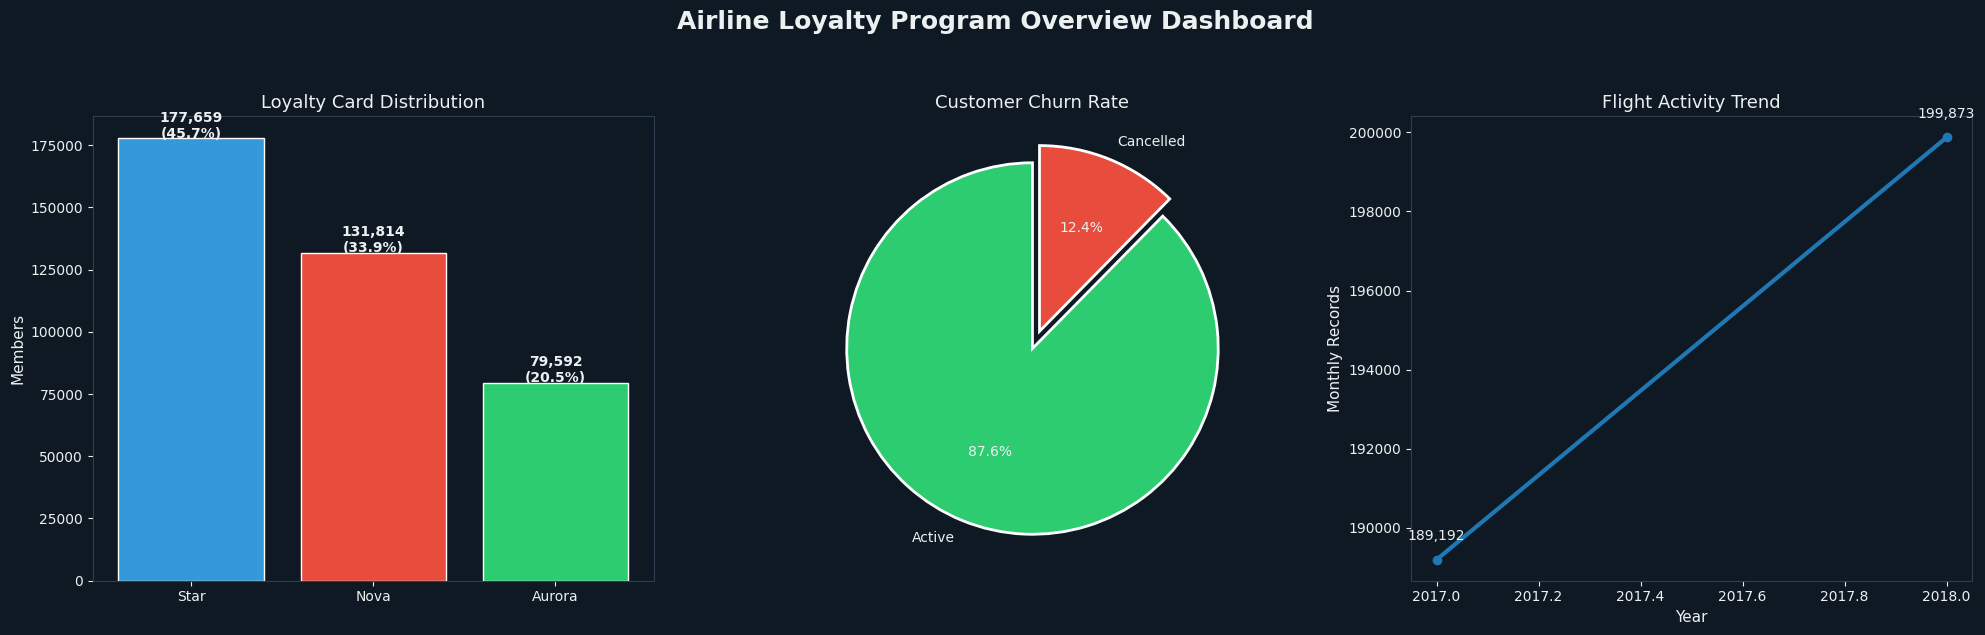

In [215]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Airline Loyalty Program Overview Dashboard',
    fontsize=18,
    fontweight='bold',
    y=1.05
)

# ==========================
# 1. Loyalty Card Distribution
# ==========================

lc = master['Loyalty Card'].value_counts()
lc_per = master['Loyalty Card'].value_counts(normalize=True) * 100

bars = axes[0].bar(
    lc.index,
    lc.values,
    color=PALETTE[:3],
    edgecolor='white',
    linewidth=1
)

axes[0].set_title('Loyalty Card Distribution')
axes[0].set_ylabel('Members')

for i, (v, p) in enumerate(zip(lc.values, lc_per)):
    axes[0].text(
        i,
        v + 50,
        f'{v:,}\n({p:.1f}%)',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ==========================
# 2. Active vs Cancelled
# ==========================

canc = master['Cancelled'].value_counts()

axes[1].pie(
    [canc[0], canc[1]],
    labels=['Active', 'Cancelled'],
    autopct='%1.1f%%',
    explode=[0, 0.1],
    colors=[GREEN, RED],
    startangle=90,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

axes[1].set_title('Customer Churn Rate')


# ==========================
# 3. Monthly Records Trend
# ==========================

yr = master.groupby('Year').size()

axes[2].plot(
    yr.index,
    yr.values,
    marker='o',
    linewidth=3
)

axes[2].set_title('Flight Activity Trend')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Monthly Records')

for x, y in zip(yr.index, yr.values):
    axes[2].text(
        x,
        y + 500,
        f'{y:,}',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### **Which cities contribute the most customers to the loyalty program?**

Why do this?
The airline wants to know:

* Which cities have the highest customer concentration
* Where marketing campaigns should be focused
* Which regions generate the most loyalty members

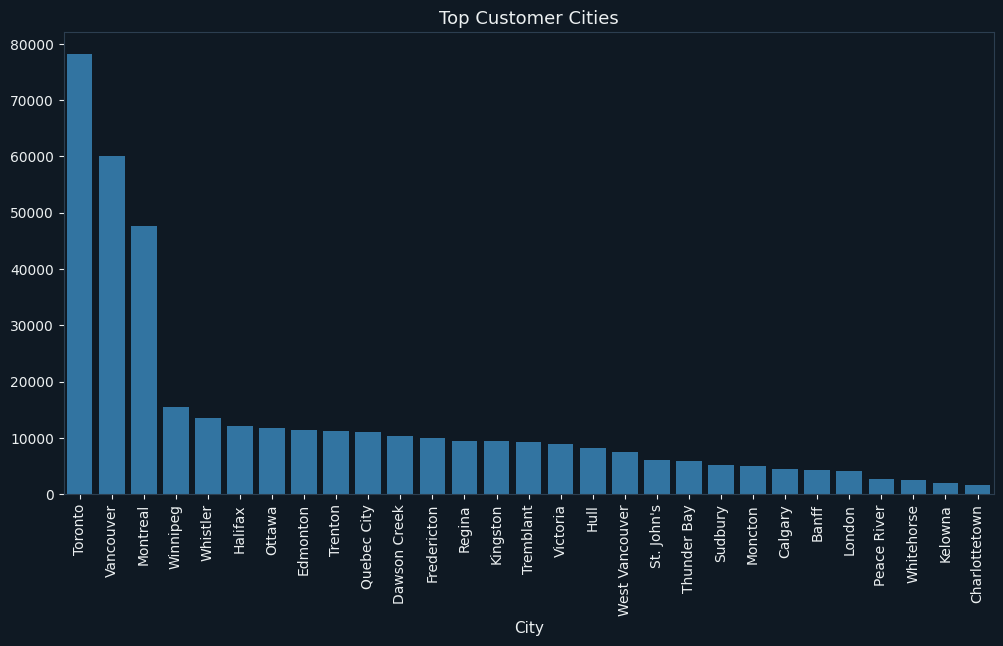

In [216]:
city_counts = master['City'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=city_counts.index,
    y=city_counts.values
)
plt.xticks(rotation=90)
plt.title('Top Customer Cities')
plt.show()

**Top 10 Cities by Customer Percentage**

In [217]:
city_per = (
    master['City']
    .value_counts(normalize=True)
    .head(10)
    .mul(100)
    .round(2)
)

city_per

City
Toronto        20.09
Vancouver      15.42
Montreal       12.24
Winnipeg        3.99
Whistler        3.49
Halifax         3.13
Ottawa          3.03
Edmonton        2.92
Trenton         2.90
Quebec City     2.85
Name: proportion, dtype: float64

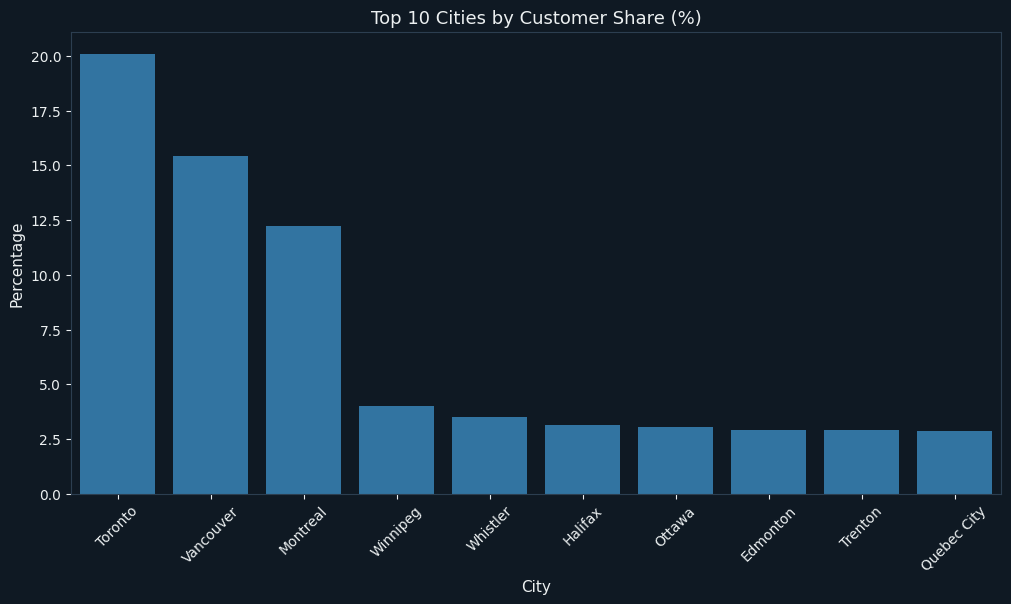

In [218]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_per.index,
    y=city_per.values
)

plt.xticks(rotation=45)
plt.ylabel('Percentage')
plt.title('Top 10 Cities by Customer Share (%)')
plt.show()

### **Distribution of Education and Salary over Enrollment Years**

Why?
The airline wants to know:

* Which education groups join the program.
* Whether high-income customers have higher enrollment.
* Whether customer demographics changed over time.

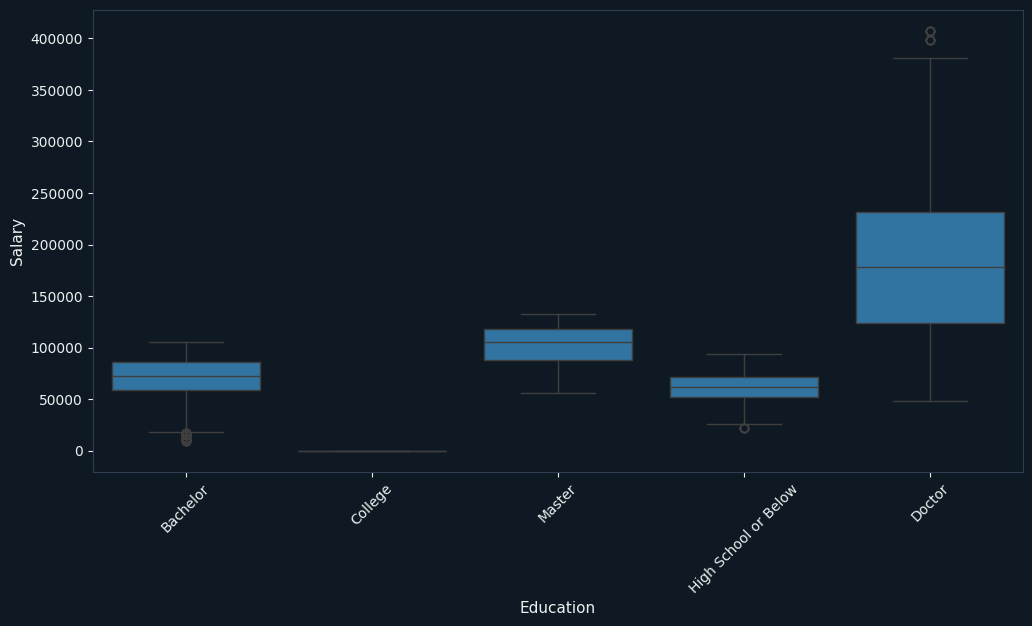

In [219]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Education',
    y='Salary',
    data=master
)

plt.xticks(rotation=45)
plt.show()

#### **Which routes are most frequently booked?**
Why?
To identify:

* Popular destinations
* Profitable routes
* Flight demand patterns

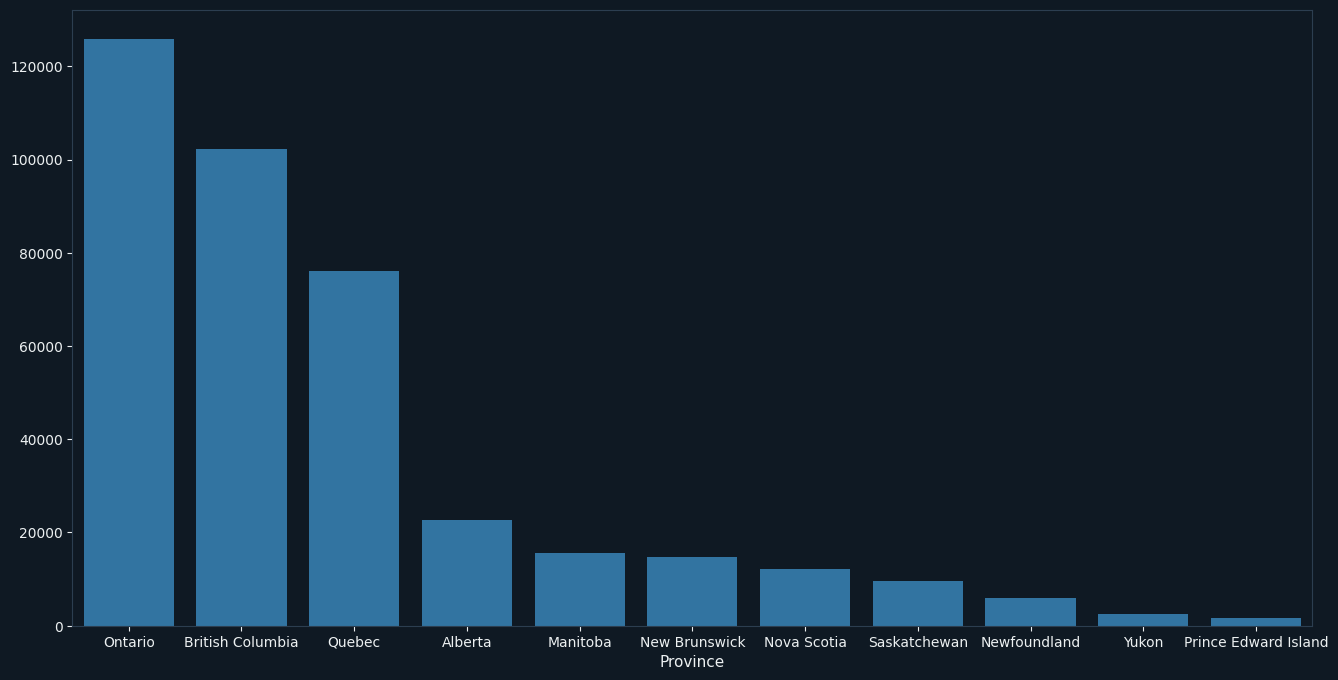

In [220]:
route_counts = master['Province'].value_counts()
plt.figure(figsize=(16,8))
           
sns.barplot(
    x=route_counts.index,
    y=route_counts.values
)
plt.show()

### **Who are the high-value customers?**

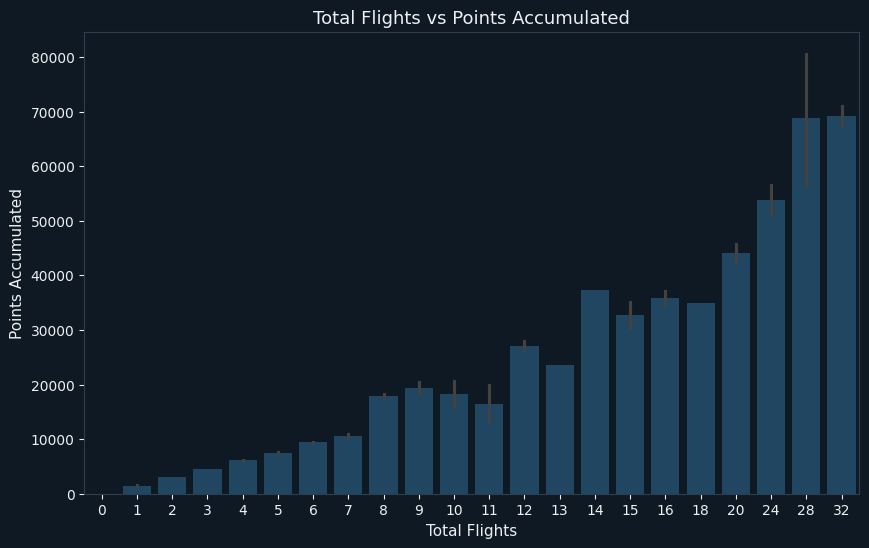

In [221]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=master,
    x='Total Flights',
    y='Points Accumulated',
    alpha=0.5
)

plt.title('Total Flights vs Points Accumulated')
plt.show()

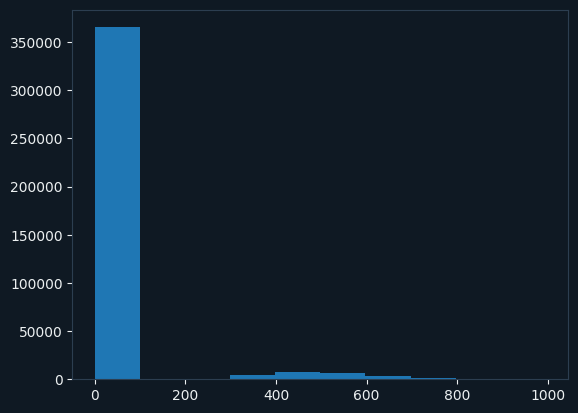

In [222]:
import matplotlib.pyplot as plt

plt.hist(master['Points Redeemed'], bins=10)
plt.show()

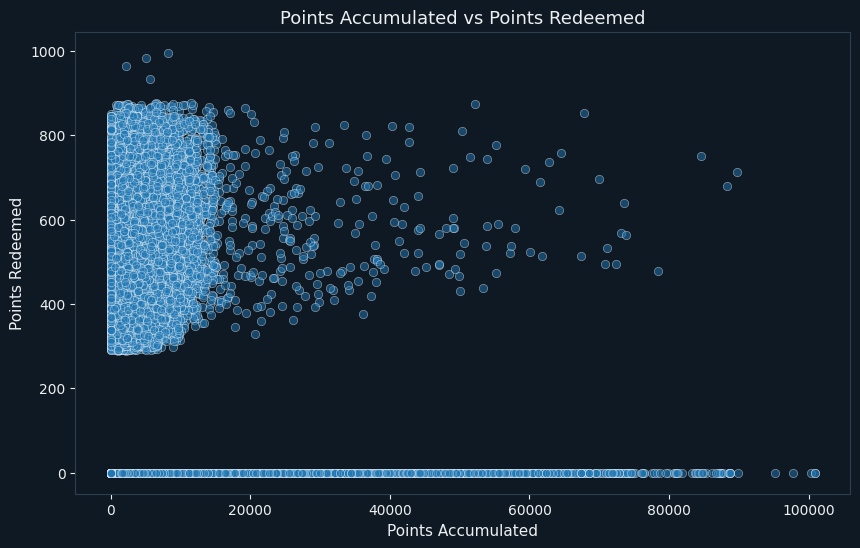

In [223]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master,
    x='Points Accumulated',
    y='Points Redeemed',
    alpha=0.5
)

plt.title('Points Accumulated vs Points Redeemed')
plt.show()

## **Loyalty Card Distribution (%)**

**Which loyalty card is most popular?**

In [224]:
card_per = (
    master['Loyalty Card']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(card_per)

Loyalty Card
Star      45.66
Nova      33.88
Aurora    20.46
Name: proportion, dtype: float64


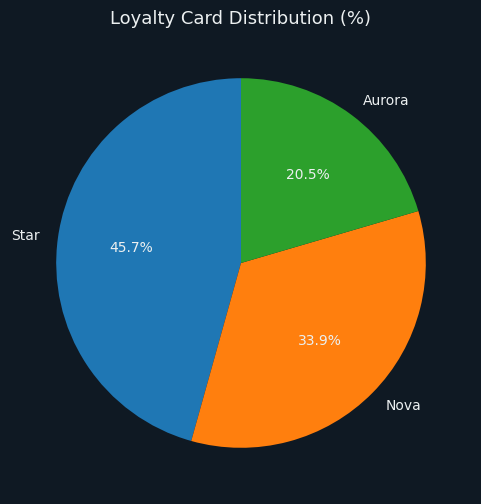

In [225]:
plt.figure(figsize=(6,6))

plt.pie(
    card_per,
    labels=card_per.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Loyalty Card Distribution (%)')
plt.show()

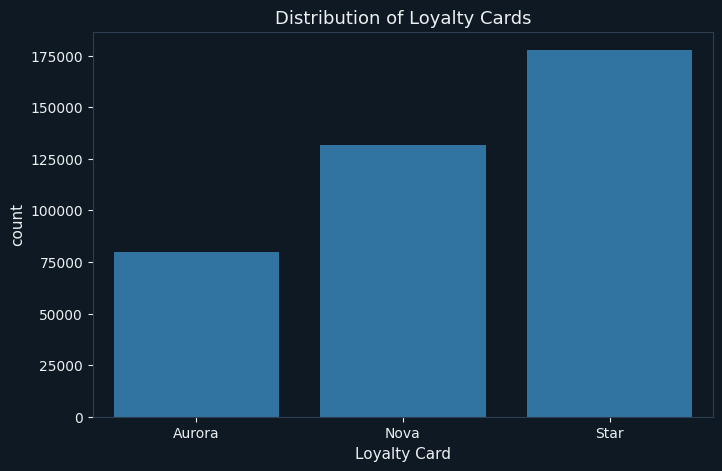

In [226]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=master,
    x='Loyalty Card'
)

plt.title('Distribution of Loyalty Cards')
plt.show()

**Points Redeemed by Loyalty Card**

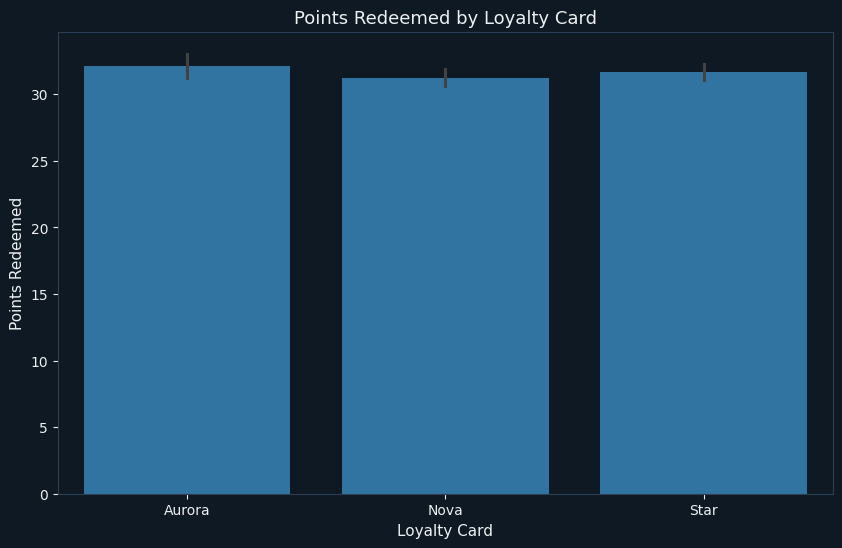

In [227]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=master,
    x='Loyalty Card',
    y='Points Redeemed'
)

plt.title('Points Redeemed by Loyalty Card')
plt.show()

**How is CLV distributed?**

<Axes: xlabel='CLV', ylabel='Count'>

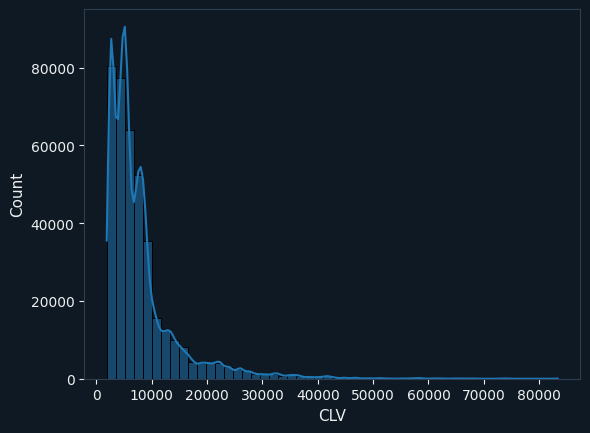

In [228]:
sns.histplot(
    master['CLV'],bins=50,
    kde=True
)

**Why?**
CLV (Customer Lifetime Value) tells:
How much revenue a customer is expected to generate.

**If distribution is right-skewed:**

This means:

Most customers have low CLV.
Few customers have very high CLV.

**Comparing CLV by Loyalty Card**

<Axes: xlabel='Loyalty Card', ylabel='CLV'>

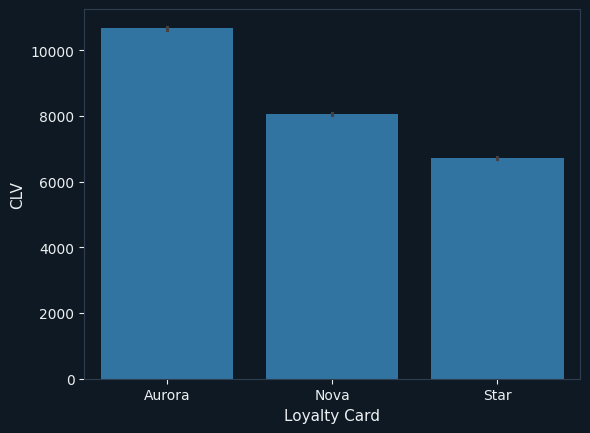

In [229]:
sns.barplot(
    x='Loyalty Card',
    y='CLV',
    data=master
)

**Which card members travel the most?**

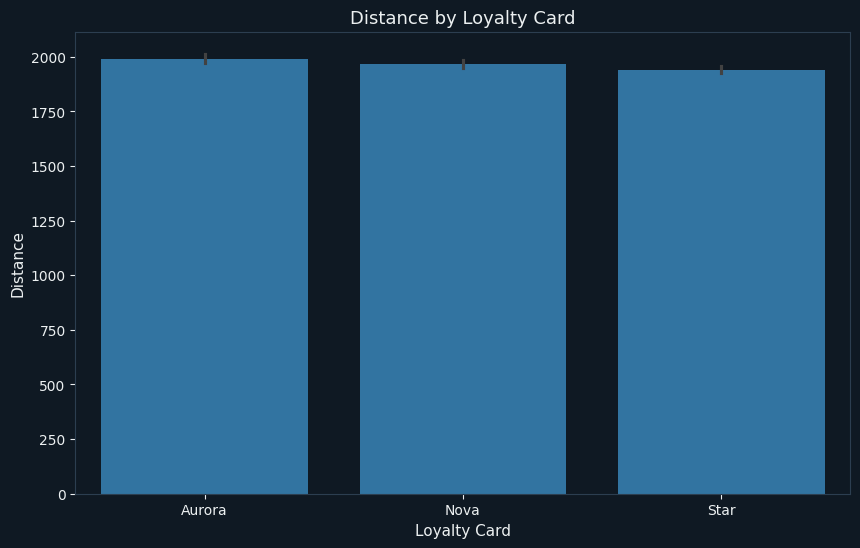

In [230]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=master,
    x='Loyalty Card',
    y='Distance'
)

plt.title('Distance by Loyalty Card')
plt.show()

**Gender Distribution**

In [231]:
gender_per = (
    master['Gender']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(gender_per)

Gender
Female    50.23
Male      49.77
Name: proportion, dtype: float64


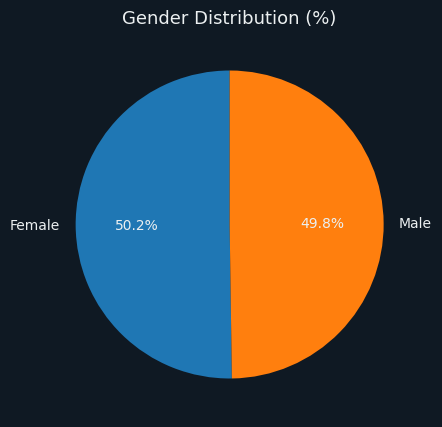

In [232]:
plt.figure(figsize=(5,5))

plt.pie(
    gender_per,
    labels=gender_per.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution (%)')
plt.show()

**Marital Status Distribution (%)**

In [233]:
marital_per = (
    master['Marital Status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(marital_per)

Marital Status
Married     58.19
Single      26.80
Divorced    15.01
Name: proportion, dtype: float64


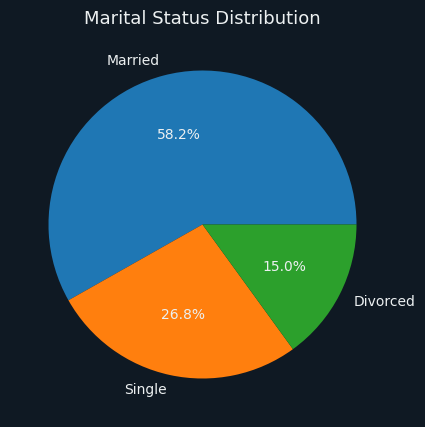

In [234]:
plt.figure(figsize=(5,5))

plt.pie(
    marital_per,
    labels=marital_per.index,
    autopct='%1.1f%%'
)

plt.title('Marital Status Distribution')
plt.show()

**Cancellation Percentage**

In [235]:
cancel_per = (
    master['Cancelled']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(cancel_per)

Cancelled
0    87.63
1    12.37
Name: proportion, dtype: float64


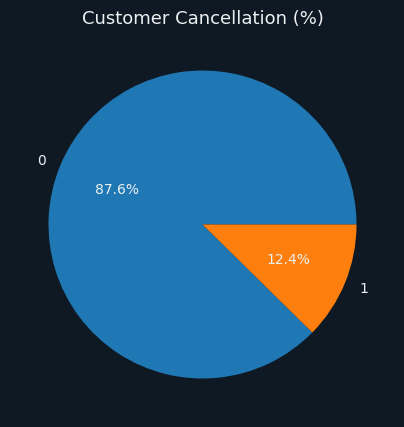

In [236]:
plt.figure(figsize=(5,5))

plt.pie(
    cancel_per,
    labels=cancel_per.index,
    autopct='%1.1f%%'
)

plt.title('Customer Cancellation (%)')
plt.show()

**Enrollment Trend Analysis**

In [237]:
enroll_trend = (
    master.groupby('Enrollment Year')
    ['Loyalty Number']
    .nunique()
)

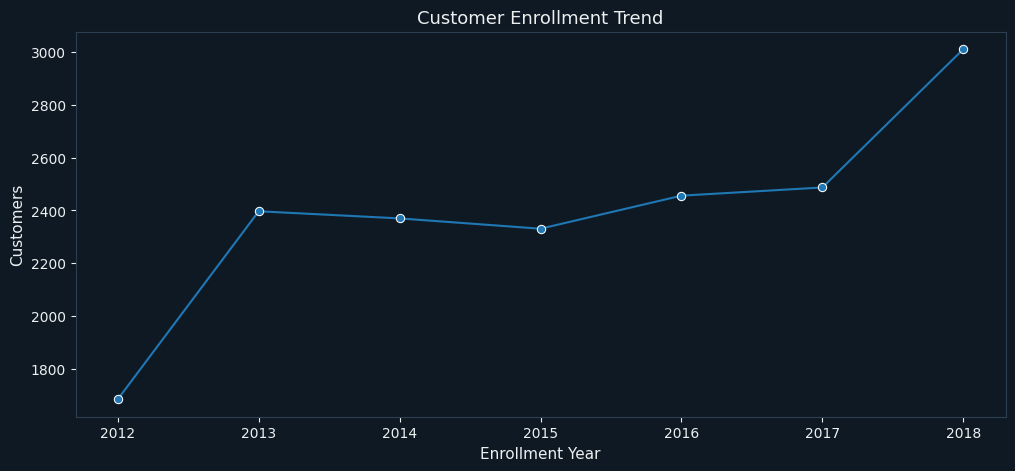

In [238]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=enroll_trend.index,
    y=enroll_trend.values,
    marker='o'
)

plt.title('Customer Enrollment Trend')
plt.xlabel('Enrollment Year')
plt.ylabel('Customers')
plt.show()

**Monthly Enrollment Trend**

In [239]:
month_trend = (
    master['Enrollment Month']
    .value_counts()
    .sort_index()
)

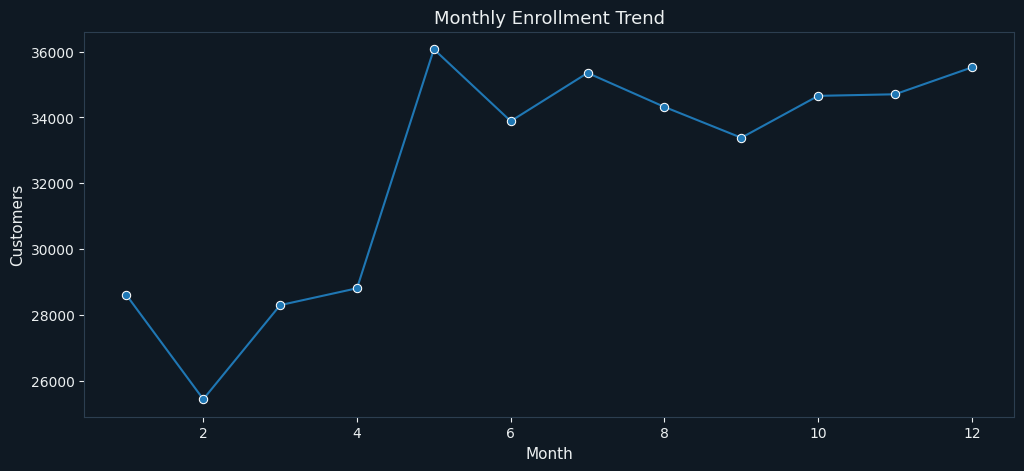

In [240]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=month_trend.index,
    y=month_trend.values,
    marker='o'
)

plt.title('Monthly Enrollment Trend')
plt.xlabel('Month')
plt.ylabel('Customers')
plt.show()

**CLV Trend by Enrollment Year**

In [241]:
clv_trend = (
    master.groupby('Enrollment Year')
    ['CLV']
    .mean()
)

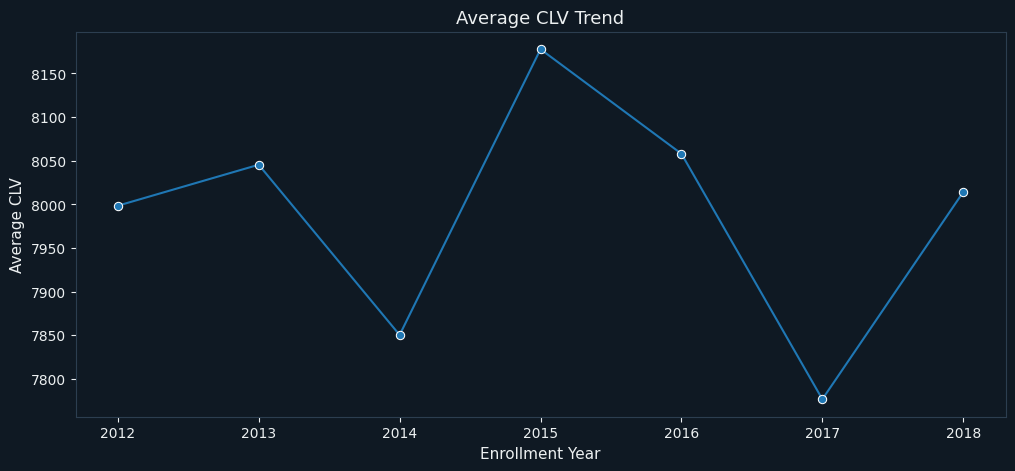

In [242]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=clv_trend.index,
    y=clv_trend.values,
    marker='o'
)

plt.title('Average CLV Trend')
plt.xlabel('Enrollment Year')
plt.ylabel('Average CLV')
plt.show()

**Churn by Loyalty Card**

In [243]:
pd.crosstab(
    master['Loyalty Card'],
    master['Cancelled'],
    normalize='index'
).mul(100).round(2)

Cancelled,0,1
Loyalty Card,,
Aurora,86.93,13.07
Nova,87.32,12.68
Star,88.18,11.82


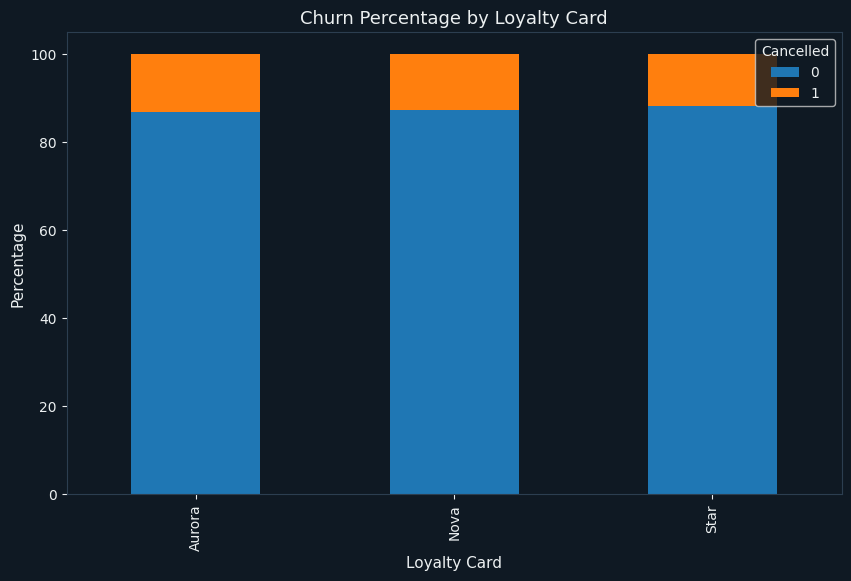

In [244]:
churn_card = pd.crosstab(
    master['Loyalty Card'],
    master['Cancelled'],
    normalize='index'
).mul(100)

churn_card.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.ylabel('Percentage')
plt.title('Churn Percentage by Loyalty Card')
plt.show()

In [245]:
total_customers = master['Loyalty Number'].nunique()

churned = master[master['Cancelled']==1]['Loyalty Number'].nunique()

churn_rate = round(
    churned/total_customers*100,
    2
)

print(f'Total Customers : {total_customers}')
print(f'Churned Customers : {churned}')
print(f'Churn Rate : {churn_rate}%')

Total Customers : 16737
Churned Customers : 2067
Churn Rate : 12.35%


In [246]:
# ==========================
# EDUCATION SUMMARY TABLE
# ==========================

print("EDUCATION ANALYSIS")
print("=" * 80)

edu_order = [
    'High School or Below',
    'College',
    'Bachelor',
    'Master',
    'Doctor'
]

edu_stats = (
    master
    .groupby('Education')
    .agg(
        Members=('Loyalty Number', 'count'),
        Avg_CLV=('CLV', 'mean'),
        Avg_Flights=('Total Flights', 'mean'),
        Cancellation_Rate=('Cancelled', 'mean')
    )
    .reindex(edu_order)
)

# Member percentage
edu_stats['Member_%'] = (
    edu_stats['Members']
    / edu_stats['Members'].sum()
    * 100
)

# Convert churn into %
edu_stats['Cancellation_Rate'] = (
    edu_stats['Cancellation_Rate']
    * 100
)

edu_stats = edu_stats.round(2)

print(edu_stats)

EDUCATION ANALYSIS
                      Members  Avg_CLV  Avg_Flights  Cancellation_Rate  \
Education                                                                
High School or Below    18118  7766.69         1.34              12.03   
College                 98618  7593.75         1.32              12.40   
Bachelor               243184  8200.70         1.30              12.32   
Master                  11945  7473.73         1.30              12.52   
Doctor                  17200  7809.52         1.29              13.09   

                      Member_%  
Education                       
High School or Below      4.66  
College                  25.35  
Bachelor                 62.50  
Master                    3.07  
Doctor                    4.42  


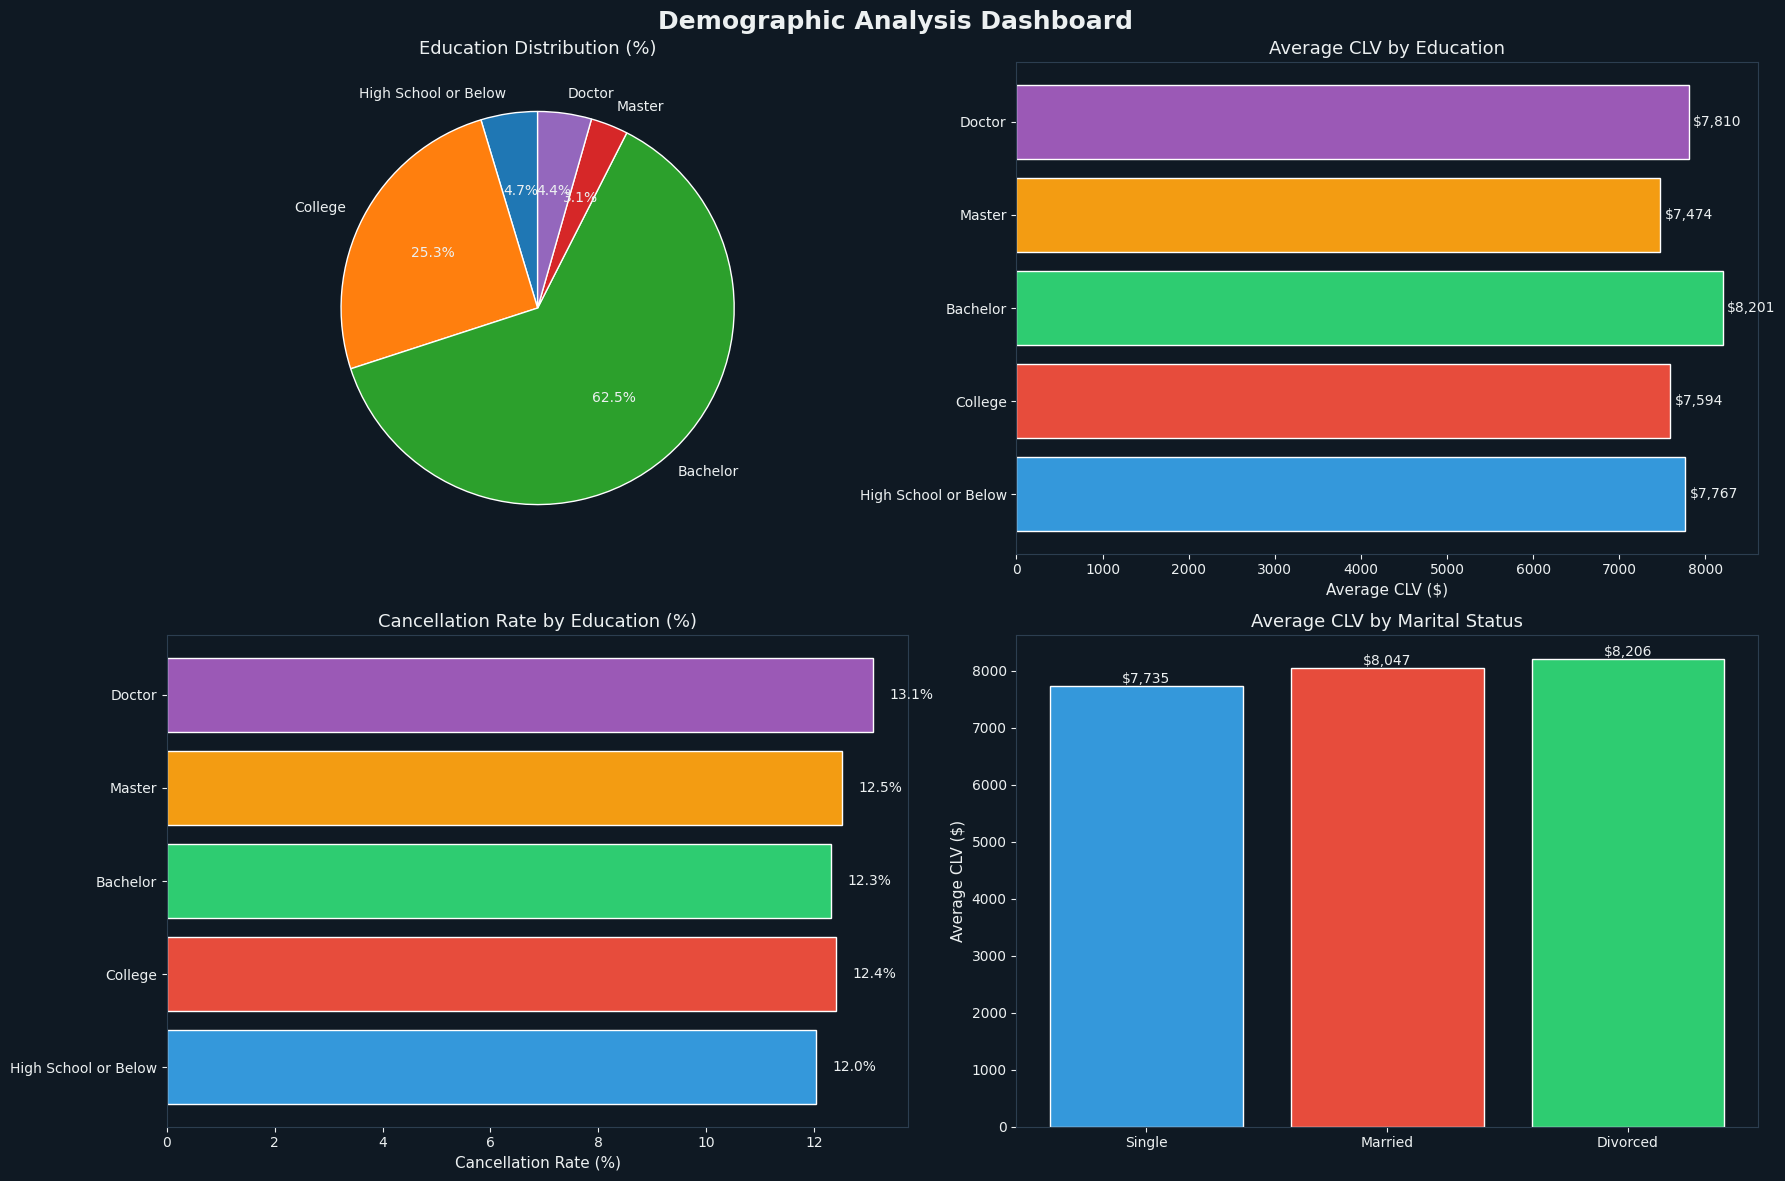

In [247]:
# ==========================
# DEMOGRAPHIC DASHBOARD
# ==========================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

fig.suptitle(
    'Demographic Analysis Dashboard',
    fontsize=18,
    fontweight='bold'
)

# =====================================
# 1. Education Distribution (%)
# =====================================

edu_per = (
    master['Education']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(edu_order)
)

axes[0,0].pie(
    edu_per,
    labels=edu_per.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={
        'edgecolor':'white',
        'linewidth':1
    }
)

axes[0,0].set_title(
    'Education Distribution (%)'
)

# =====================================
# 2. Average CLV by Education
# =====================================

edu_clv = (
    master.groupby('Education')
    ['CLV']
    .mean()
    .reindex(edu_order)
)

axes[0,1].barh(
    edu_clv.index,
    edu_clv.values,
    color=PALETTE[:5],
    edgecolor='white'
)

axes[0,1].set_title(
    'Average CLV by Education'
)

axes[0,1].set_xlabel(
    'Average CLV ($)'
)

for i, v in enumerate(edu_clv.values):

    axes[0,1].text(
        v + 50,
        i,
        f'${v:,.0f}',
        va='center'
    )

# =====================================
# 3. Cancellation Rate by Education
# =====================================

edu_canc = (
    master.groupby('Education')
    ['Cancelled']
    .mean()
    .mul(100)
    .reindex(edu_order)
)

axes[1,0].barh(
    edu_canc.index,
    edu_canc.values,
    color=PALETTE[:5],
    edgecolor='white'
)

axes[1,0].set_title(
    'Cancellation Rate by Education (%)'
)

axes[1,0].set_xlabel(
    'Cancellation Rate (%)'
)

for i, v in enumerate(edu_canc.values):

    axes[1,0].text(
        v + 0.3,
        i,
        f'{v:.1f}%',
        va='center'
    )

# =====================================
# 4. Average CLV by Marital Status
# =====================================

mar_clv = (
    master.groupby('Marital Status')
    ['CLV']
    .mean()
    .sort_values()
)

axes[1,1].bar(
    mar_clv.index,
    mar_clv.values,
    color=PALETTE[:3],
    edgecolor='white'
)

axes[1,1].set_title(
    'Average CLV by Marital Status'
)

axes[1,1].set_ylabel(
    'Average CLV ($)'
)

for i, v in enumerate(mar_clv.values):

    axes[1,1].text(
        i,
        v + 50,
        f'${v:,.0f}',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    'demographic_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

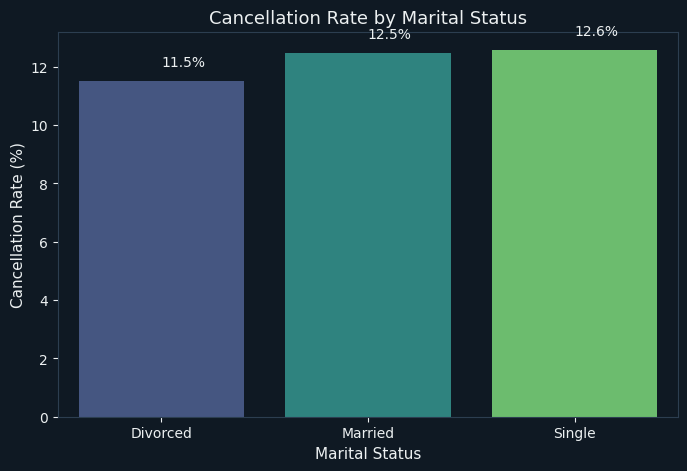

In [248]:
# =====================================
# CHURN BY MARITAL STATUS
# =====================================

mar_churn = (
    master.groupby('Marital Status')
    ['Cancelled']
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=mar_churn.index,
    y=mar_churn.values,
    palette='viridis'
)

plt.title(
    'Cancellation Rate by Marital Status'
)

plt.ylabel(
    'Cancellation Rate (%)'
)

for i, v in enumerate(mar_churn.values):

    plt.text(
        i,
        v + 0.5,
        f'{v:.1f}%'
    )

plt.show()

In [249]:
import calendar
import numpy as np

monthly = (
    master
    .groupby(['Year', 'Month'])
    .agg(
        Total_Flights=('Total Flights', 'sum'),
        Total_Distance=('Distance', 'sum'),
        Total_Points_Acc=('Points Accumulated', 'sum'),
        Total_Points_Red=('Points Redeemed', 'sum'),
        Active_Customers=(
            'Loyalty Number',
            lambda x: x[
                master.loc[x.index, 'Total Flights'] > 0
            ].nunique()
        )
    )
    .reset_index()
)

monthly['Period'] = (
    monthly['Month']
    .apply(lambda x: calendar.month_abbr[x])
    + ' '
    + monthly['Year'].astype(str)
)

In [250]:
monthly['Flight_Growth_%'] = (
    monthly['Total_Flights']
    .pct_change()
    .mul(100)
    .round(2)
)

monthly['Point_Growth_%'] = (
    monthly['Total_Points_Acc']
    .pct_change()
    .mul(100)
    .round(2)
)

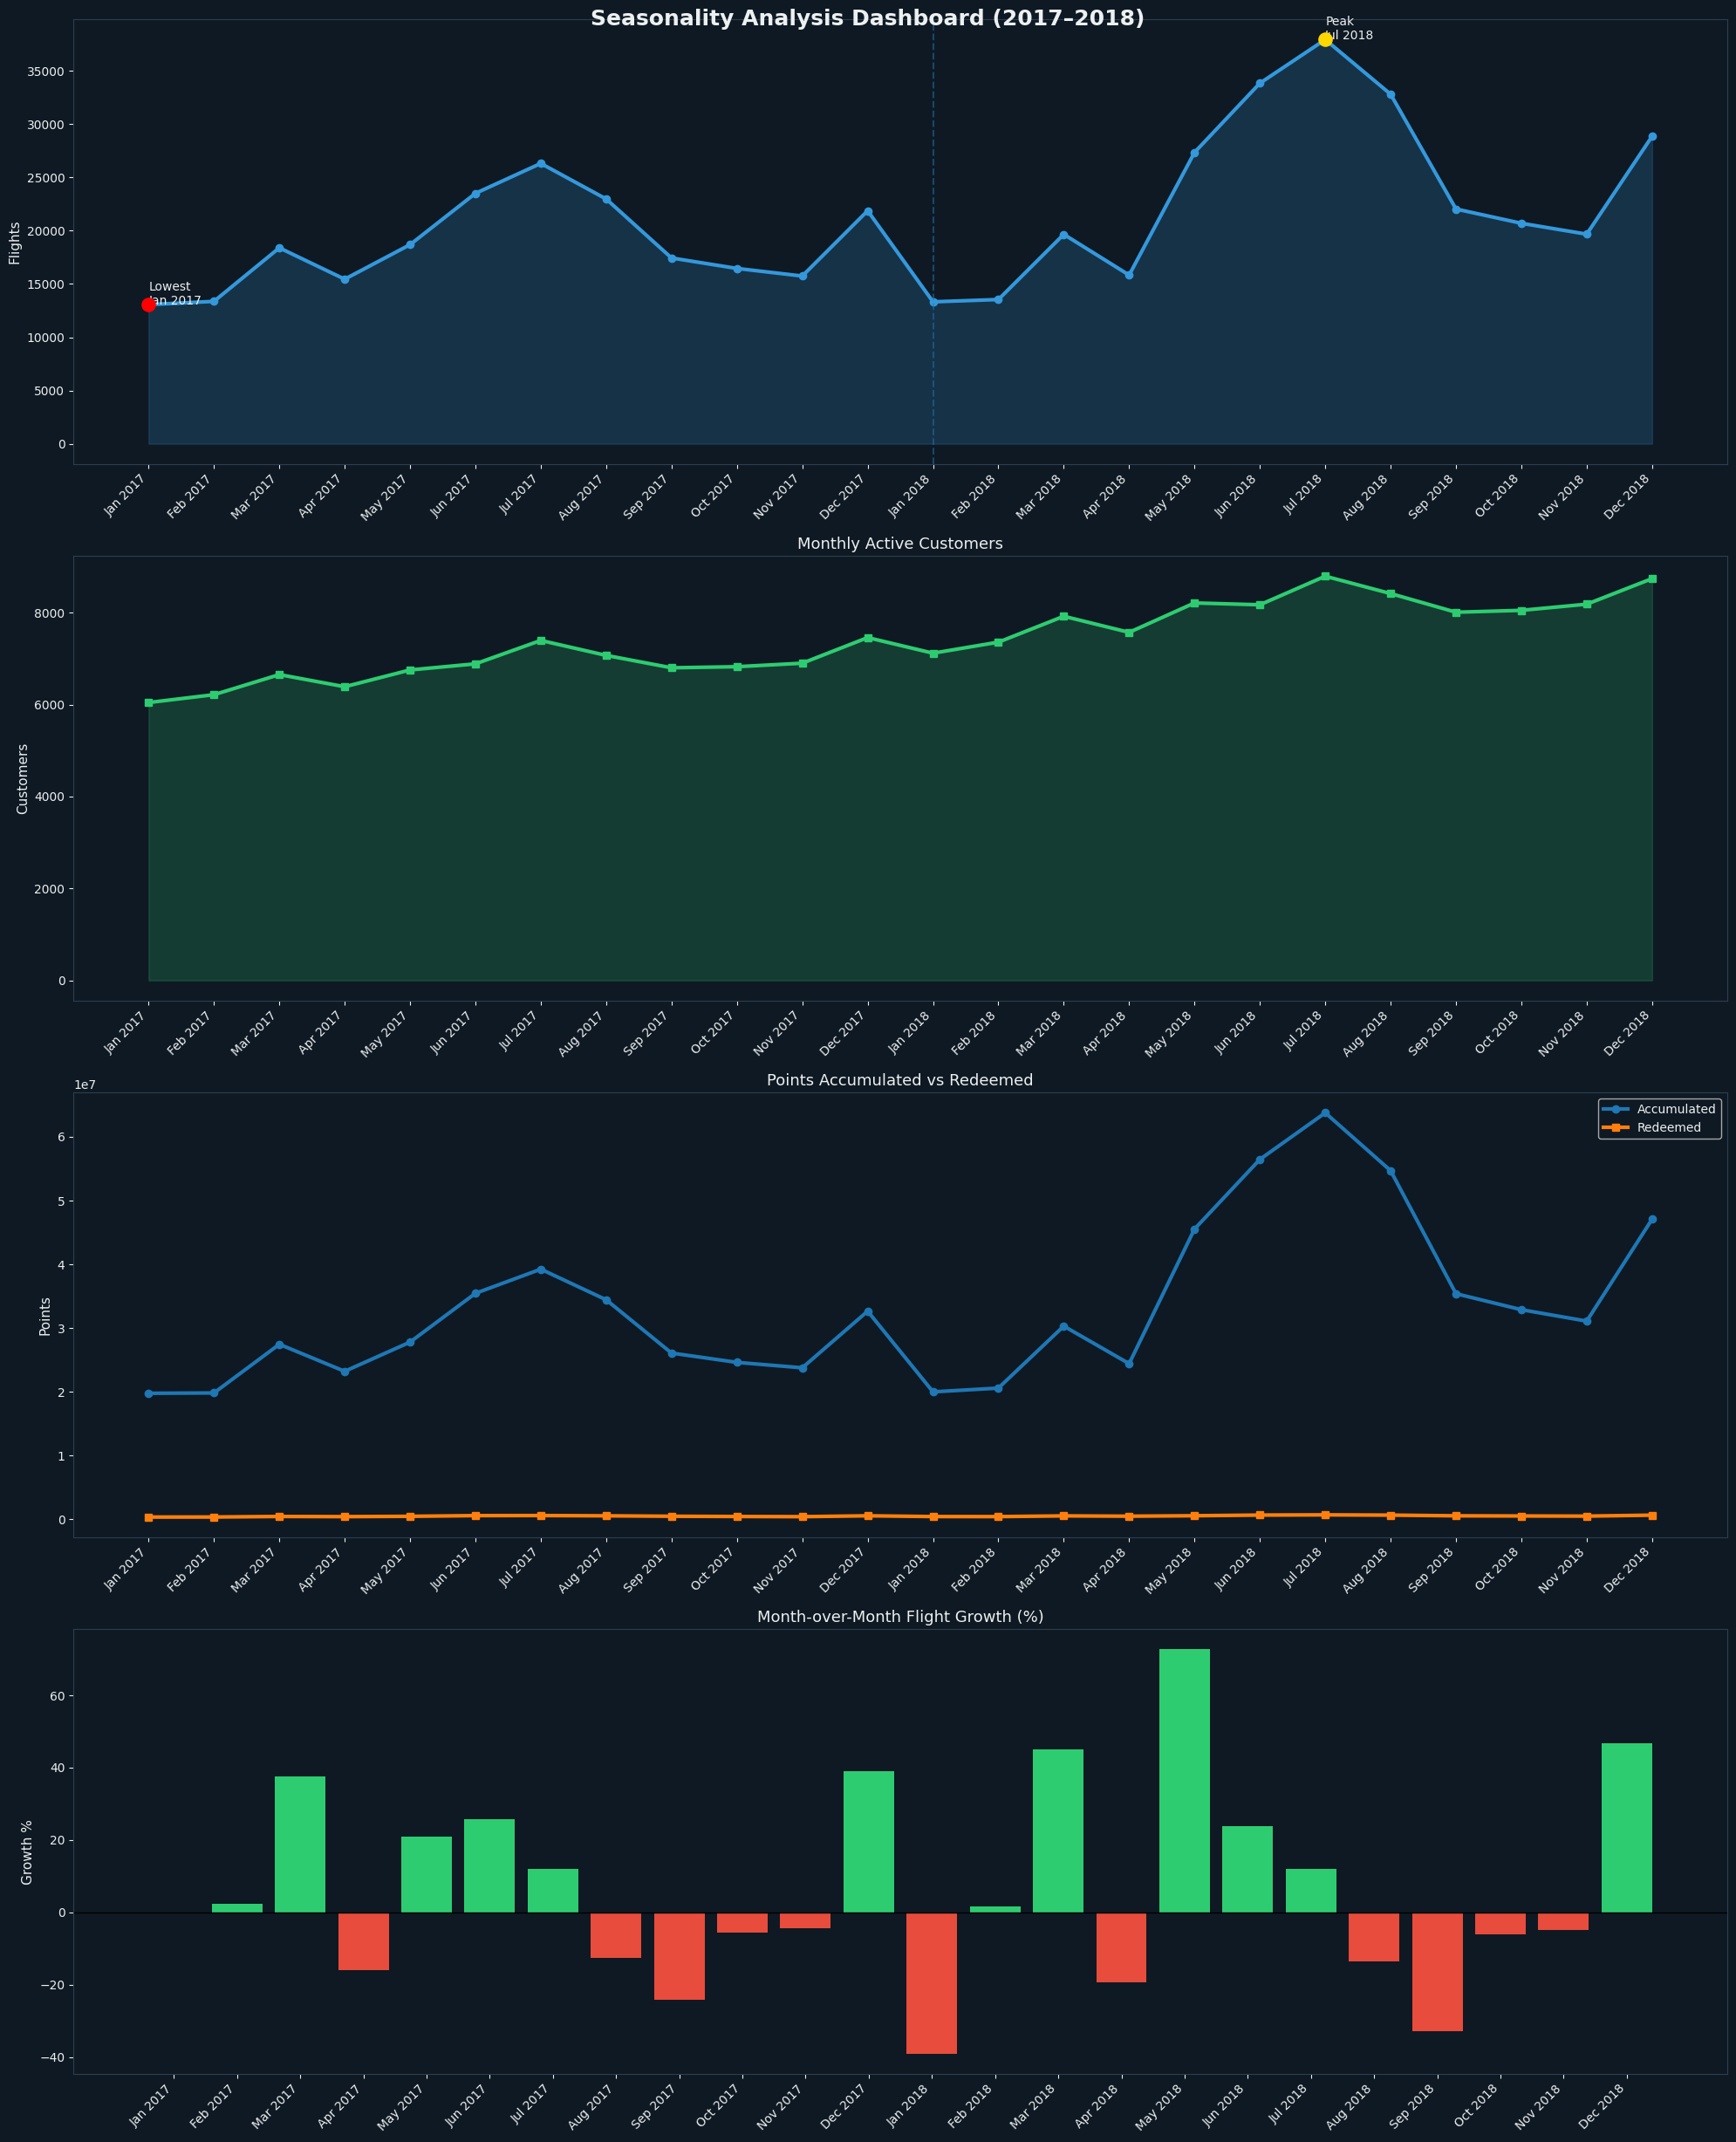

In [251]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(20, 25)
)

fig.suptitle(
    'Seasonality Analysis Dashboard (2017–2018)',
    fontsize=18,
    fontweight='bold'
)

x = np.arange(len(monthly))
labels = monthly['Period']

# =====================================
# 1. Total Flights Trend
# =====================================

axes[0].plot(
    x,
    monthly['Total_Flights'],
    marker='o',
    linewidth=3,
    color=BLUE
)

axes[0].fill_between(
    x,
    monthly['Total_Flights'],
    alpha=0.20,
    color=BLUE
)

# axes[0].set_title('Monthly Total Flights')
axes[0].set_ylabel('Flights')

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    labels,
    rotation=45,
    ha='right'
)

peak_idx = monthly['Total_Flights'].idxmax()
low_idx = monthly['Total_Flights'].idxmin()

axes[0].scatter(
    peak_idx,
    monthly.loc[peak_idx, 'Total_Flights'],
    s=120,
    color='gold',
    zorder=5
)

axes[0].scatter(
    low_idx,
    monthly.loc[low_idx, 'Total_Flights'],
    s=120,
    color='red',
    zorder=5
)

axes[0].annotate(
    f"Peak\n{monthly.loc[peak_idx,'Period']}",
    (
        peak_idx,
        monthly.loc[peak_idx,'Total_Flights']
    )
)

axes[0].annotate(
    f"Lowest\n{monthly.loc[low_idx,'Period']}",
    (
        low_idx,
        monthly.loc[low_idx,'Total_Flights']
    )
)

axes[0].axvline(
    12,
    linestyle='--',
    alpha=0.5
)

# =====================================
# 2. Active Customers Trend
# =====================================

axes[1].plot(
    x,
    monthly['Active_Customers'],
    marker='s',
    linewidth=3,
    color=GREEN
)

axes[1].fill_between(
    x,
    monthly['Active_Customers'],
    alpha=0.20,
    color=GREEN
)

axes[1].set_title('Monthly Active Customers')
axes[1].set_ylabel('Customers')

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    labels,
    rotation=45,
    ha='right'
)

# =====================================
# 3. Points Accumulated vs Redeemed
# =====================================

axes[2].plot(
    x,
    monthly['Total_Points_Acc'],
    marker='o',
    linewidth=3,
    label='Accumulated'
)

axes[2].plot(
    x,
    monthly['Total_Points_Red'],
    marker='s',
    linewidth=3,
    label='Redeemed'
)

axes[2].set_title(
    'Points Accumulated vs Redeemed'
)

axes[2].set_ylabel('Points')

axes[2].legend()

axes[2].set_xticks(x)
axes[2].set_xticklabels(
    labels,
    rotation=45,
    ha='right'
)

# =====================================
# 4. MoM Flight Growth
# =====================================

colors = [
    GREEN if i >= 0 else RED
    for i in monthly['Flight_Growth_%'].fillna(0)
]

axes[3].bar(
    x,
    monthly['Flight_Growth_%'].fillna(0),
    color=colors
)

axes[3].axhline(
    0,
    color='black',
    linewidth=1
)

axes[3].set_title(
    'Month-over-Month Flight Growth (%)'
)

axes[3].set_ylabel(
    'Growth %'
)

axes[3].set_xticks(x)
axes[3].set_xticklabels(
    labels,
    rotation=45,
    ha='right'
)

plt.tight_layout()

plt.savefig(
    'seasonality_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Customer Segmentation Discovery**

In [252]:
cust_seg = master.groupby('Loyalty Number').agg(
    Total_Flights=('Total Flights', 'sum'),
    Total_Distance=('Distance', 'sum'),
    Total_Points_Acc=('Points Accumulated', 'sum'),
    Total_Points_Red=('Points Redeemed', 'sum'),
    CLV=('CLV', 'first'),
    Cancelled=('Cancelled', 'first'),
    Active_Months=('Month', 'nunique')
).reset_index()

In [253]:
cust_seg = cust_seg.merge(
    master[
        [
            'Loyalty Number',
            'Salary',
            'Loyalty Card',
            'Education',
            'Gender',
            'Marital Status'
        ]
    ].drop_duplicates(),
    on='Loyalty Number',
    how='left'
)

In [254]:
cust_seg['Redemption_Rate'] = np.where(
    cust_seg['Total_Points_Acc'] == 0,
    0,
    cust_seg['Total_Points_Red']
    / cust_seg['Total_Points_Acc']
)

In [255]:
cust_seg['Card_Num'] = (
    cust_seg['Loyalty Card']
    .map(
        {
            'Star':1,
            'Nova':2,
            'Aurora':3
        }
    )
)

In [256]:
clv_75 = cust_seg['CLV'].quantile(0.75)

flight_75 = (
    cust_seg['Total_Flights']
    .quantile(0.75)
)

flight_25 = (
    cust_seg['Total_Flights']
    .quantile(0.25)
)

In [257]:
def prelim_segment(row):

    high_clv = row['CLV'] >= clv_75

    high_flight = (
        row['Total_Flights']
        >= flight_75
    )

    low_flight = (
        row['Total_Flights']
        <= flight_25
    )

    high_red = (
        row['Redemption_Rate']
        >= 0.30
    )

    inactive = (
        row['Active_Months']
        < 3
    )

    if (
        high_clv
        and high_flight
        and high_red
    ):
        return 'Champions'

    elif (
        high_clv
        and high_flight
    ):
        return 'Loyal Customers'

    elif (
        high_clv
        and inactive
    ):
        return 'Dormant High Value'

    elif (
        not high_clv
        and high_flight
        and inactive
    ):
        return 'At Risk Members'

    elif (
        low_flight
        and not inactive
    ):
        return 'Casual Travelers'

    else:
        return 'Frequent Flyers'

In [258]:
cust_seg['Prelim_Segment'] = (
    cust_seg.apply(
        prelim_segment,
        axis=1
    )
)

In [259]:
seg_profile = (
    cust_seg.groupby(
        'Prelim_Segment'
    )
    .agg(
        Members=('Loyalty Number','count'),
        Avg_CLV=('CLV','mean'),
        Avg_Flights=('Total_Flights','mean'),
        Avg_Redemption=('Redemption_Rate','mean'),
        Avg_Active_Months=('Active_Months','mean'),
        Cancelled_Rate=('Cancelled','mean')
    )
)

seg_profile['Member_%'] = (
    seg_profile['Members']
    / seg_profile['Members'].sum()
    * 100
)

seg_profile['Cancelled_Rate'] = (
    seg_profile['Cancelled_Rate']
    * 100
)

seg_profile = (
    seg_profile
    .sort_values(
        'Avg_CLV',
        ascending=False
    )
    .round(2)
)

print(
    "\nPRELIMINARY CUSTOMER PERSONA PROFILES\n"
)

print(seg_profile)


PRELIMINARY CUSTOMER PERSONA PROFILES

                  Members   Avg_CLV  Avg_Flights  Avg_Redemption  \
Prelim_Segment                                                     
Loyal Customers      1123  16549.10        49.30            0.01   
Casual Travelers     4299   8127.68         6.69            0.01   
Frequent Flyers     11315   7086.58        37.53            0.02   

                  Avg_Active_Months  Cancelled_Rate  Member_%  
Prelim_Segment                                                 
Loyal Customers               11.86            1.69      6.71  
Casual Travelers              11.98           39.43     25.69  
Frequent Flyers               11.94            3.12     67.60  


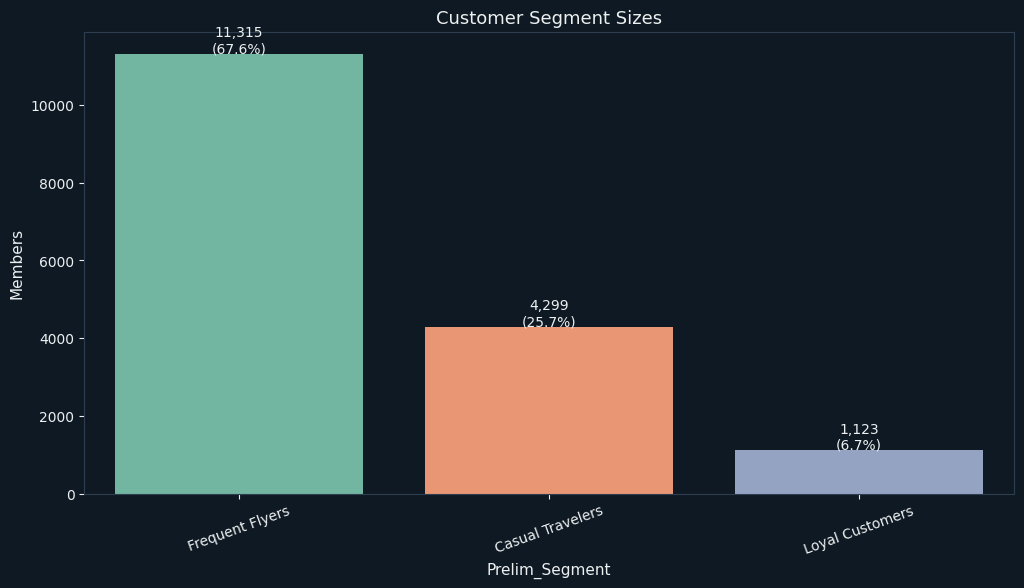

In [260]:
plt.figure(figsize=(12,6))

seg_counts = (
    cust_seg['Prelim_Segment']
    .value_counts()
)

sns.barplot(
    x=seg_counts.index,
    y=seg_counts.values,
    palette='Set2'
)

plt.title(
    'Customer Segment Sizes'
)

plt.ylabel(
    'Members'
)

plt.xticks(rotation=20)

for i, v in enumerate(seg_counts.values):

    plt.text(
        i,
        v + 20,
        f'{v:,}\n({v/len(cust_seg):.1%})',
        ha='center'
    )

plt.show()

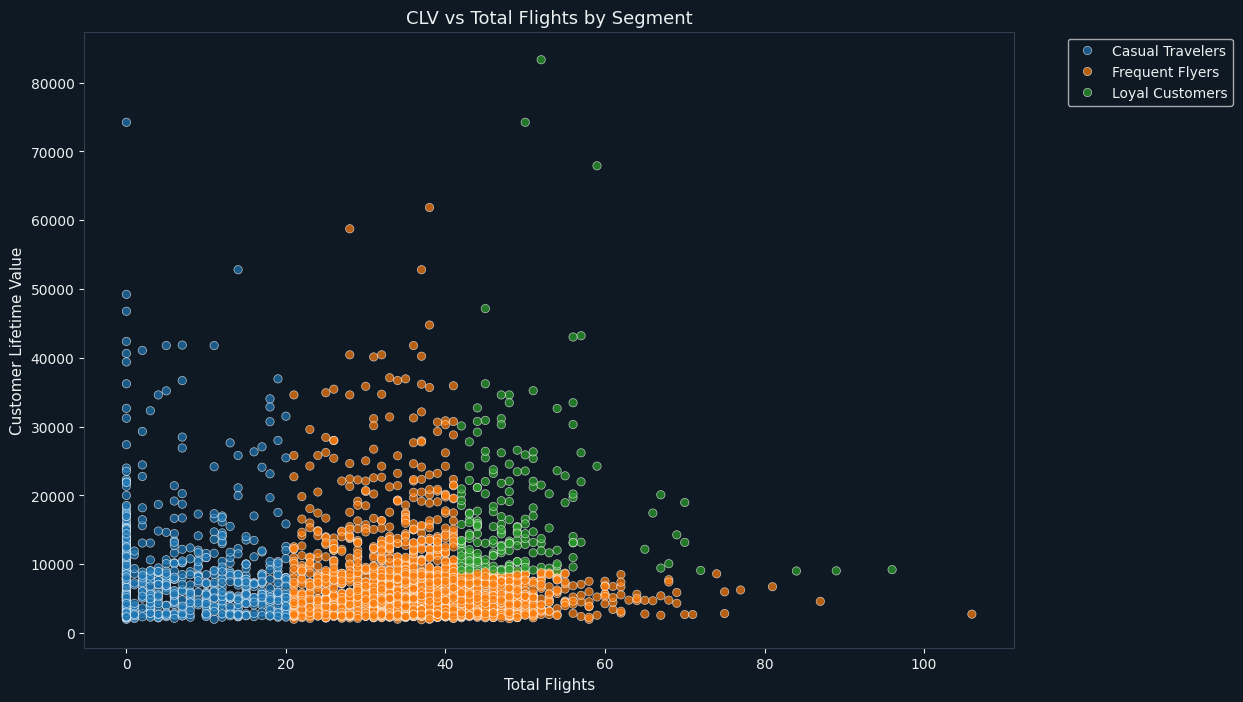

In [261]:
plt.figure(figsize=(12,8))

sample = cust_seg.sample(
    min(3000, len(cust_seg)),
    random_state=42
)

sns.scatterplot(
    data=sample,
    x='Total_Flights',
    y='CLV',
    hue='Prelim_Segment',
    alpha=0.7
)

plt.title(
    'CLV vs Total Flights by Segment'
)

plt.xlabel(
    'Total Flights'
)

plt.ylabel(
    'Customer Lifetime Value'
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.show()